# Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique used to reduce the number of variables in a dataset while preserving as much information as possible.

It transforms the original variables into a new set of variables called **principal components**, which are orthogonal to each other and capture the maximum variance in the data.

---

# Data Representation

Suppose we have a dataset

$$
X \in \mathbb{R}^{m \times n}
$$

where

- $m$ = number of samples
- $n$ = number of features

Each row represents an observation and each column represents a feature.

---

# Step 1: Centering the Data

The first step in PCA is to center the dataset by subtracting the mean of each feature.

Let

$$
\mu = \frac{1}{m}\sum_{i=1}^{m} x_i
$$

The centered data matrix is

$$
X_{centered} = X - \mu
$$

Centering ensures that the data has mean zero.

---

# Step 2: Covariance Matrix

Next we compute the covariance matrix

$$
\Sigma = \frac{1}{m-1} X_{centered}^T X_{centered}
$$

The covariance matrix describes how the variables vary together.

If the covariance between two variables is large, it means they are strongly correlated.

---

# Step 3: Eigenvalue Decomposition

We compute the eigenvalues and eigenvectors of the covariance matrix.

$$
\Sigma v = \lambda v
$$

where

- $v$ = eigenvector
- $\lambda$ = eigenvalue

The eigenvectors represent directions in which the data varies the most.

The eigenvalues represent the amount of variance captured by each direction.

---

# Step 4: Principal Components

The eigenvectors corresponding to the largest eigenvalues are called **principal components**.

If

$$
\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_n
$$

then the first principal component corresponds to $\lambda_1$.

The matrix of principal components is

$$
W = [v_1, v_2, \dots , v_k]
$$

where $k < n$.

---

# Step 5: Projection onto Lower Dimensions

The data is projected onto the principal component directions.

$$
Z = X_{centered} W
$$

where

- $Z$ is the reduced data matrix
- $W$ contains the principal components.

This transforms the data from $n$ dimensions to $k$ dimensions.

---

# Explained Variance

Each eigenvalue represents the amount of variance captured by its corresponding principal component.

The explained variance ratio is

$$
\frac{\lambda_i}{\sum_{j=1}^{n} \lambda_j}
$$

This measures how much information each component preserves.

---

# PCA using Singular Value Decomposition

Instead of computing eigenvectors of the covariance matrix, PCA can also be computed using Singular Value Decomposition.

Let

$$
X = U \Sigma V^T
$$

Then

- columns of $V$ are the principal components
- singular values determine the variance explained.

---

# Geometric Interpretation

PCA finds new coordinate axes such that

1. The first axis captures the maximum variance.
2. The second axis captures the next largest variance and is orthogonal to the first.
3. This continues for all remaining axes.

Thus PCA rotates the coordinate system to align with the directions of maximum variance.

---

# Dimensionality Reduction

If we keep only the first $k$ principal components

$$
Z = X_{centered} W_k
$$

we obtain a lower-dimensional representation of the data that preserves most of the variance.

---






In [ ]:
import numpy as np

In [ ]:
A = np.array([[2,3,4],[3,5,7],[4,6,8],[5,8,11]])

In [ ]:
A

array([[ 2,  3,  4],
       [ 3,  5,  7],
       [ 4,  6,  8],
       [ 5,  8, 11]])

In [ ]:
mean = np.mean(A, axis=0)

In [ ]:
print(mean)

[3.5 5.5 7.5]


In [ ]:
A

array([[ 2,  3,  4],
       [ 3,  5,  7],
       [ 4,  6,  8],
       [ 5,  8, 11]])

In [ ]:
A_centered = mean - A

In [ ]:
cov_matrix = np.cov(A_centered.T)

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [ ]:
print(cov_matrix)

[[1.66666667 2.66666667 3.66666667]
 [2.66666667 4.33333333 6.        ]
 [3.66666667 6.         8.33333333]]


In [ ]:
idx = np.argsort(eigenvalues)[::-1]

In [ ]:
eigenvalues

array([ 1.42866698e+01,  4.66635456e-02, -1.31803000e-15])

In [ ]:
eigenvalues = eigenvalues[idx]

In [ ]:
eigenvectors = eigenvectors[:,idx]

In [ ]:
W = eigenvectors[:,:2]

In [ ]:
print("projection matrix:=", W)

projection matrix:= [[-0.33809817 -0.84795222]
 [-0.55064932 -0.17354729]
 [-0.76320047  0.50085764]]


In [ ]:
Z = A_centered@W

In [ ]:
print("reduced data:=",Z)

reduced data:= [[-4.55497219  0.04720519]
 [-0.82597398 -0.26032093]
 [ 0.82597398  0.26032093]
 [ 4.55497219 -0.04720519]]


**Here is different method to solve the PCA using library**

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=2)

In [ ]:
pca.fit_transform(A)

array([[-4.55497219,  0.04720519],
       [-0.82597398, -0.26032093],
       [ 0.82597398,  0.26032093],
       [ 4.55497219, -0.04720519]])

# Swiss Roll Dataset

The Swiss Roll dataset is a synthetic dataset commonly used to demonstrate dimensionality reduction techniques.

The dataset consists of points lying on a two–dimensional surface that is rolled into a spiral shape in three–dimensional space.

Although the data appears to be three-dimensional, the intrinsic dimensionality of the data is actually two.

This means that the data lies on a **2D manifold embedded in 3D space**.

---

# Mathematical Description

Let the dataset be

$$
X = (x_1, x_2, x_3)
$$

where each point lies on a spiral surface.

The variable $t$ represents the position along the spiral.

Thus the dataset can be parameterized by

$$
x_1 = t \cos(t)
$$

$$
x_2 = h
$$

$$
x_3 = t \sin(t)
$$

where

- $t$ controls the spiral position
- $h$ represents the vertical coordinate.

---

# Purpose of the Swiss Roll Example

The Swiss Roll dataset is used to illustrate the difference between

- **linear dimensionality reduction**
- **nonlinear manifold learning**

Although the data lives on a two–dimensional surface, projecting it linearly using PCA may cause overlapping because PCA performs a linear projection.

Thus PCA does not perfectly "unroll" the Swiss roll.

This motivates the use of nonlinear dimensionality reduction methods such as

- Locally Linear Embedding (LLE)
- Isomap
- t-SNE

which attempt to recover the underlying manifold structure.

---

# Visualizing the Swiss Roll

In the following section we generate the Swiss Roll dataset and visualize it in three-dimensional space.

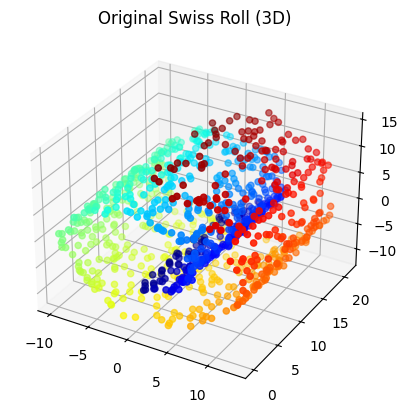

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.decomposition import PCA

# Step 1: Generate swiss roll dataset
X, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)

# Step 2: Plot the 3D swiss roll
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c=t, cmap='jet')
ax.set_title("Original Swiss Roll (3D)")
plt.show()

# PCA on the Swiss Roll

We now apply Principal Component Analysis to the Swiss Roll dataset.

PCA finds directions of maximum variance in the data and projects the data onto a lower-dimensional subspace.

However, PCA is a **linear method**.  
Since the Swiss Roll is a **nonlinear manifold**, PCA cannot perfectly unroll the spiral.

Instead, PCA produces a flattened projection where different layers of the spiral may overlap.

This example demonstrates the limitation of linear dimensionality reduction methods when applied to nonlinear structures.

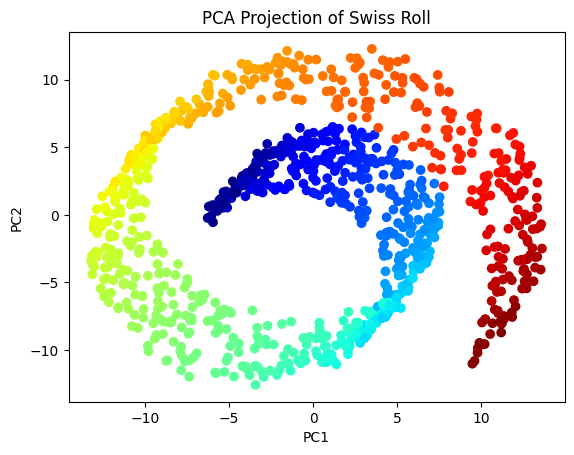

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_reduced = pca.fit_transform(X)

plt.scatter(X_reduced[:,0], X_reduced[:,1], c=t, cmap='jet')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Swiss Roll")

plt.show()